[*********************100%***********************]  5 of 5 completed

Macro-market correlation analysis
Downloaded 3518 trading days.
              S&P 500  Treasury 10Y         Gold          Oil  US Dollar
Date                                                                    
2023-12-22  73.559998    101.699997  2057.100098  4754.629883      3.901
2023-12-26  75.570000    101.470001  2058.199951  4774.750000      3.886
2023-12-27  74.110001    100.989998  2081.899902  4781.580078      3.789
2023-12-28  71.769997    101.230003  2073.899902  4783.350098      3.850
2023-12-29  71.650002    101.330002  2062.399902  4769.830078      3.866


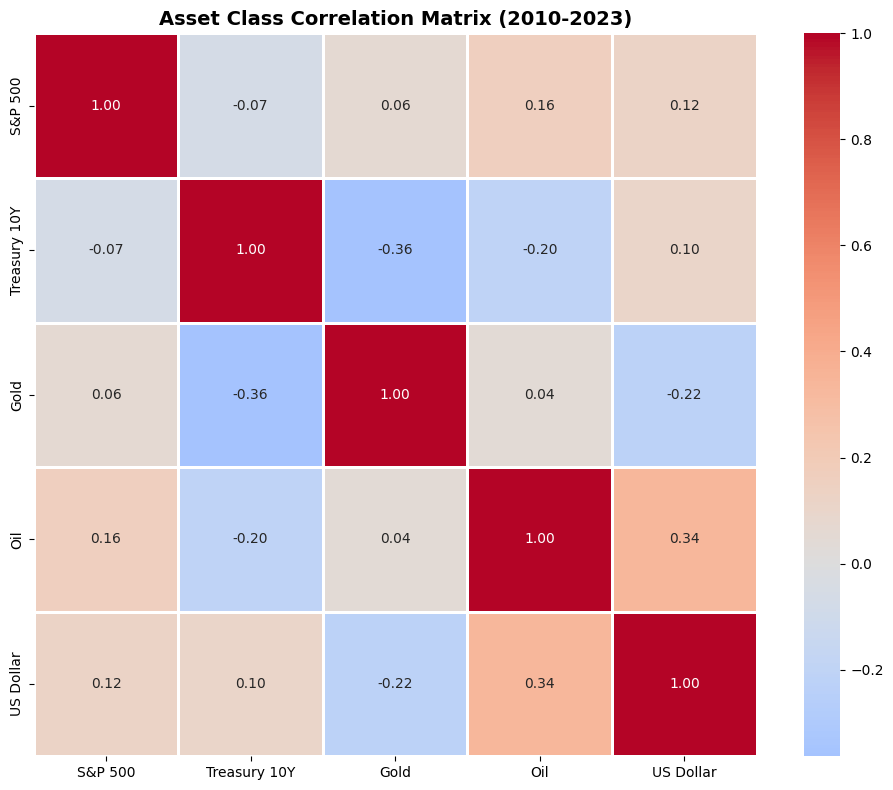

Key observations:
1. Stocks vs Bonds: historically negative (diversification works).
2. Gold vs Dollar: strong negative (gold is the anti-dollar).
3. Oil vs Stocks: usually positive (growth drives both).


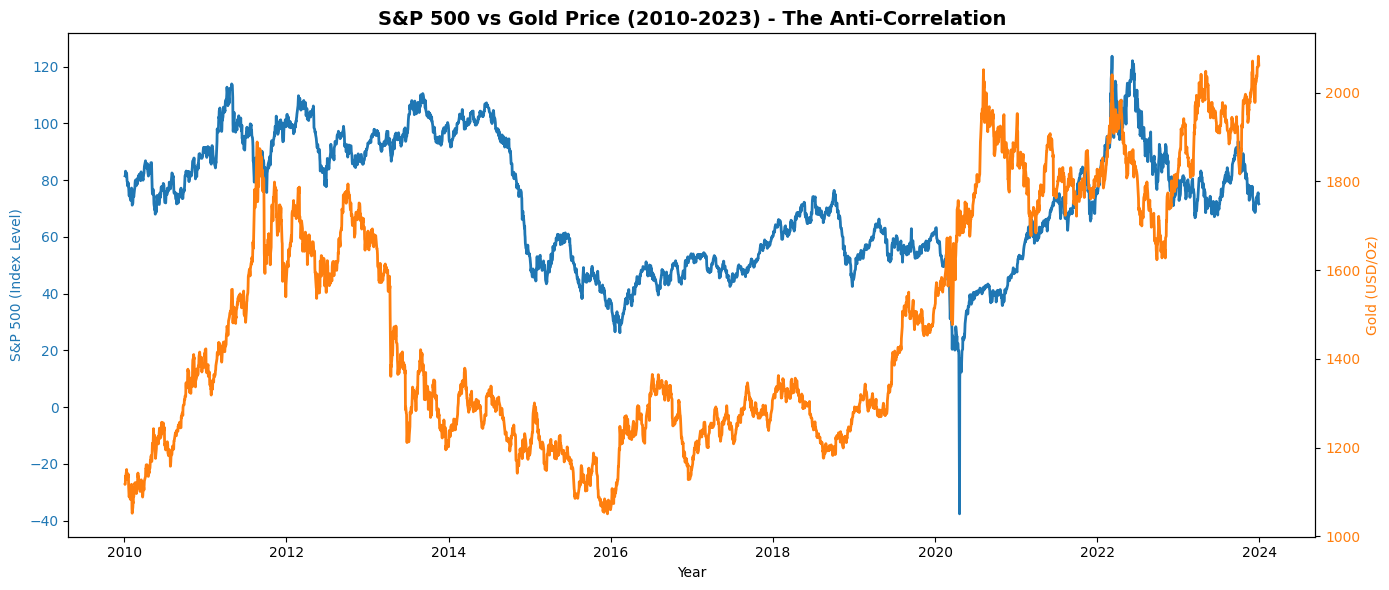

Data saved to 'macro_market_data.csv'


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Macro-market correlation analysis")

# ------------------------------------------------------------
# 1. Download market data (S&P 500, 10Y Treasury, Gold, Oil, USD Index)
# ------------------------------------------------------------
tickers = ['^GSPC', '^TNX', 'GC=F', 'CL=F', 'DX-Y.NYB']
names = ['S&P 500', 'Treasury 10Y', 'Gold', 'Oil', 'US Dollar']

print("Downloading 10 years of market data...")
data = yf.download(tickers, start='2010-01-01', end='2023-12-31')['Close']
data.columns = names
data = data.dropna()

print(f"Downloaded {len(data)} trading days.")
print(data.tail())

# ------------------------------------------------------------
# 2. Daily returns
# ------------------------------------------------------------
returns = data.pct_change().dropna()

# ------------------------------------------------------------
# 3. Correlation heatmap
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))
corr = returns.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Asset Class Correlation Matrix (2010-2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('asset_correlation_heatmap.png', dpi=300)
plt.show()

print("Key observations:")
print("1. Stocks vs Bonds: historically negative (diversification works).")
print("2. Gold vs Dollar: strong negative (gold is the anti-dollar).")
print("3. Oil vs Stocks: usually positive (growth drives both).")

# ------------------------------------------------------------
# 4. Dual-axis chart: S&P 500 vs Gold
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('S&P 500 (Index Level)', color=color1)
ax1.plot(data.index, data['S&P 500'], color=color1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Gold (USD/Oz)', color=color2)
ax2.plot(data.index, data['Gold'], color=color2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('S&P 500 vs Gold Price (2010-2023) - The Anti-Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sp500_vs_gold.png', dpi=300)
plt.show()

# ------------------------------------------------------------
# 5. Save data for further use
# ------------------------------------------------------------
data.to_csv('macro_market_data.csv')
print("Data saved to 'macro_market_data.csv'")